In [30]:
import pandas as pd
import ace_tools_open as tools
import matplotlib.pyplot as plt

In [31]:
# Cálculo dos momentos fletores nas seções
secoes = [f"S{i}" for i in range(1, 12)]
secoes

['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11']

In [32]:
# Inicializando valores de momento fletor
momentos_perm = [round(7.5 * (i * 0.2) - 3.75 * (i * 0.2) ** 2, 2) for i in
                 range(0, 11)]  # Momento fletor devido à carga permanente
momentos_perm.pop(-1)
momentos_perm.append(0)
momentos_perm

[0.0, 1.35, 2.4, 3.15, 3.6, 3.75, 3.6, 3.15, 2.4, 1.35, 0]

In [33]:
momentos_movel_max = [round(12 * (2 - 0.2 * i) * (0.2 * i / 2), 2) for i in range(0, 11)]  # Momento máximo
momentos_movel_max.pop(-1)
momentos_movel_max.append(0)
momentos_movel_max

[0.0, 2.16, 3.84, 5.04, 5.76, 6.0, 5.76, 5.04, 3.84, 2.16, 0]

In [34]:
momentos_movel_min = [round(-4 * 0.2 * i, 2) for i in range(0, 11)]  # Momento mínimo
momentos_movel_min.pop(-1)
momentos_movel_min.append(0)
momentos_movel_min

[-0.0, -0.8, -1.6, -2.4, -3.2, -4.0, -4.8, -5.6, -6.4, -7.2, 0]

In [35]:
# Envoltórias
envoltoria_max = [round(momentos_perm[i] + momentos_movel_max[i], 2) for i in range(11)]
envoltoria_min = [round(momentos_perm[i] + momentos_movel_min[i], 2) for i in range(11)]
envoltoria_max, envoltoria_min

([0.0, 3.51, 6.24, 8.19, 9.36, 9.75, 9.36, 8.19, 6.24, 3.51, 0],
 [0.0, 0.55, 0.8, 0.75, 0.4, -0.25, -1.2, -2.45, -4.0, -5.85, 0])

In [39]:
# Criando a tabela de envoltória
df = pd.DataFrame({
    "Seção": secoes,
    "Mperm (kN.m)": momentos_perm,
    "Maior + (kN.m)": momentos_movel_max,
    "Maior - (kN.m)": momentos_movel_min,
    "Max (kN.m)": envoltoria_max,
    "Min (kN.m)": envoltoria_min
})
df.index = df['Seção']
df = df.iloc[:, 1:]
# Exibir tabela
df.head(11)


,Mperm (kN.m),Maior + (kN.m),Maior - (kN.m),Max (kN.m),Min (kN.m)
Seção,,,,,
S1,0.00,0.00,-0.0,0.00,0.00
S2,1.35,2.16,-0.8,3.51,0.55
S3,2.40,3.84,-1.6,6.24,0.80
S4,3.15,5.04,-2.4,8.19,0.75
S5,3.60,5.76,-3.2,9.36,0.40
S6,3.75,6.00,-4.0,9.75,-0.25
S7,3.60,5.76,-4.8,9.36,-1.20
S8,3.15,5.04,-5.6,8.19,-2.45
S9,2.40,3.84,-6.4,6.24,-4.00


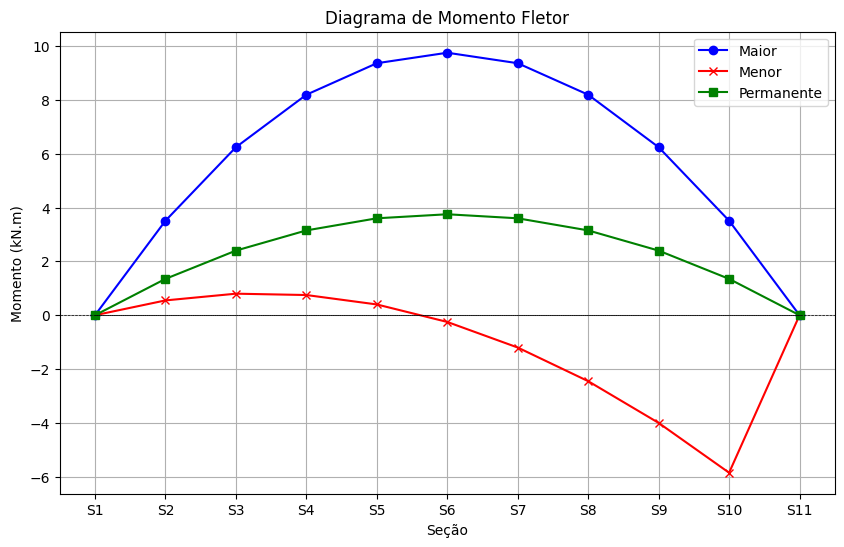

In [37]:
    # Plotando o gráfico
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(secoes, envoltoria_max, label="Maior", color='b', marker='o')
ax.plot(secoes, envoltoria_min, label="Menor", color='r', marker='x')
ax.plot(secoes, momentos_perm, label="Permanente", color='g', marker='s')
ax.plot(secoes, [0] * 11, color='black', linewidth=0.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title("Diagrama de Momento Fletor")
ax.set_xlabel("Seção")
ax.set_ylabel("Momento (kN.m)")
ax.legend()
ax.grid()
plt.show()